Streaming output truncated to the last 5000 lines.
    - c76057a5fad2ede8.jpg
    - c76238859837f921.jpg
    - c762b0a693b99418.jpg
    - c76d52d8a0ed31a2.jpg
    - c76fefb3b0fff193.jpg
    - c77095a52b680e88.jpg
    - c771981a7fc8dd1c.jpg
    - c77563e8bd4cf786.jpg
    - c77ad5e4afeea33c.jpg
    - c77be5bb5fb7e75c.jpg
    - c77fc23dbd3037f1.jpg
    - c78c757e5cf0a304.jpg
    - c78e400cbd1f8f48.jpg
    - c7917151c7a0b016.jpg
    - c792317b0483e4b6.jpg
    - c7a4af67badec548.jpg
    - c7a9f686f14914e0.jpg
    - c7abd19c75171c4a.jpg
    - c7b560a4a615af34.jpg
    - c7ba731691765c73.jpg
    - c7c325f60db40e63.jpg
    - c7c677cedda46e99.jpg
    - c7c7fd9b44e91577.jpg
    - c7cb29ea1473a323.jpg
    - c7d2a62962cfb538.jpg
    - c7daace88d1f2ad8.jpg
    - c7dc149d2c02ef47.jpg
    - c7e04af692e6c681.jpg
    - c7e1736be70bfac6.jpg
    - c7f6abe2766e2fbe.jpg
    - c7fa15d79ce503cb.jpg
    - c7fe0794cdb51b76.jpg
    - c8017893d8ef6d54.jpg
    - c806988c4fa53cec.jpg
    - c8142b8a85f17f51.jpg
    

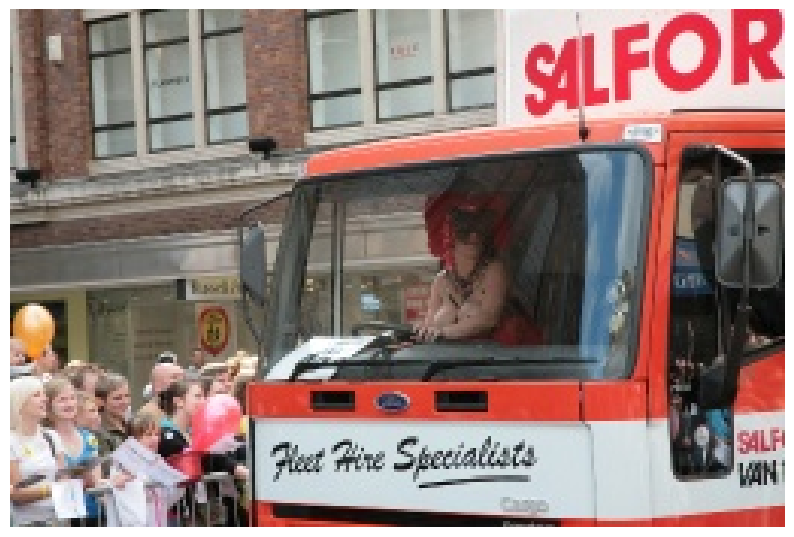

In [4]:
# 1 cell to debug + run (paste into Colab)
import os, glob, zipfile
from pathlib import Path
import pprint

# --- adjust this if you unzipped elsewhere ---
ROOT = "/content/dataset_split_r"

print("ROOT exists?", os.path.exists(ROOT))
print("\nListing top-level contents of /content:")
for p in sorted(os.listdir("/content")):
    print(" ", p)

# If the folder exists, show tree (depth 3)
def show_tree(root, max_depth=3):
    root = Path(root)
    if not root.exists():
        print(f"\nPath not found: {root}")
        return
    print(f"\nFolder tree for {root}:")
    def walk(p, depth):
        if depth>max_depth: return
        indent = "  " * depth
        try:
            items = sorted(p.iterdir())
        except Exception:
            return
        for it in items:
            print(f"{indent}- {it.name}{'/' if it.is_dir() else ''}")
            if it.is_dir():
                walk(it, depth+1)
    walk(root, 0)

show_tree(ROOT, max_depth=3)

# --- robust recursive image search (common extensions) ---
exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.tif","*.tiff")
def find_images(folder):
    folder = Path(folder)
    imgs = []
    for e in exts:
        imgs += list(folder.rglob(e))
    return sorted(imgs)

train_candidates = []
test_candidates = []

# Try common locations
possible_train_dirs = [
    Path(ROOT)/"train",
    Path(ROOT)/"Train",
    Path(ROOT)/"training",
    Path(ROOT)/"train_images",
    Path(ROOT)
]
possible_test_dirs = [
    Path(ROOT)/"test",
    Path(ROOT)/"Test",
    Path(ROOT)/"testing",
    Path(ROOT)/"test_images",
    Path(ROOT)
]

# Collect images (first non-empty result)
for d in possible_train_dirs:
    imgs = find_images(d)
    if imgs:
        train_candidates = imgs
        print(f"\nUsing train images from: {d}")
        break

for d in possible_test_dirs:
    imgs = find_images(d)
    if imgs:
        test_candidates = imgs
        print(f"\nUsing test images from: {d}")
        break

print(f"\n# train images found: {len(train_candidates)}")
print(f"# test images found : {len(test_candidates)}")

if len(train_candidates)==0 or len(test_candidates)==0:
    raise FileNotFoundError(
        "No train/test images found. Check your zip's internal structure.\n"
        "Use the printed folder tree above to see where images are located."
    )

# convert to str paths
train_images = [str(p) for p in train_candidates]
test_images  = [str(p) for p in test_candidates]

print("\nExample train images (first 5):")
pprint.pprint(train_images[:5])
print("\nExample test images (first 5):")
pprint.pprint(test_images[:5])

# --- now safe to import heavy libs and continue ---
!pip install -q opencv-python-headless scikit-learn tensorflow joblib

import cv2, numpy as np, matplotlib.pyplot as plt
from sklearn.svm import SVC
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
import joblib

# load first images (safe now)
train_image = cv2.imread(train_images[0])
test_image  = cv2.imread(test_images[0])

if train_image is None or test_image is None:
    raise RuntimeError("cv2.imread failed (maybe file is corrupted or path wrong). See printed paths.")

# Selective Search (may require ximgproc)
# If ximgproc not available, fall back to simple sliding windows (warning: slow)
def get_region_proposals(image):
    try:
        ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
        ss.setBaseImage(image)
        ss.switchToSelectiveSearchFast()
        return ss.process()
    except Exception as e:
        print("Selective Search not available (cv2.ximgproc). Falling back to coarse grid windows.")
        h,w = image.shape[:2]
        rects=[]
        step = min(w,h)//8
        for y in range(0,h,step):
            for x in range(0,w,step):
                ww = min(step, w-x)
                hh = min(step, h-y)
                rects.append((x,y,ww,hh))
        return rects

vgg = VGG16(weights="imagenet", include_top=False, pooling='avg')

def extract_feature(region):
    region = cv2.resize(region, (224,224))
    region = img_to_array(region)
    region = np.expand_dims(region, axis=0)
    region = preprocess_input(region)
    feature = vgg.predict(region)
    return feature.flatten()

# Train on first train image (example approach)
rects = get_region_proposals(train_image)
X,y = [],[]
for (x,y1,w,h) in rects[:200]:
    roi = train_image[y1:y1+h, x:x+w]
    if roi.size==0: continue
    X.append(extract_feature(roi))
    y.append(1 if len(y)<25 else 0)
X = np.array(X); y = np.array(y)

print("\nTraining SVM on", X.shape[0], "regions...")
svm = SVC(kernel="linear", probability=True)
svm.fit(X,y)
print("SVM trained.")

# detect on first test image
test_rects = get_region_proposals(test_image)
out = test_image.copy()
for (x,y1,w,h) in test_rects[:300]:
    roi = test_image[y1:y1+h, x:x+w]
    if roi.size==0: continue
    p = svm.predict_proba([extract_feature(roi)])[0][1]
    if p>0.80:
        cv2.rectangle(out, (x,y1),(x+w,y1+h),(0,255,0),2)

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


Validation set size: 60
Accuracy : 0.7333
Precision: 0.0909
Recall   : 0.1429
F1-score : 0.1111

Confusion Matrix:
 [[43 10]
 [ 6  1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.81      0.84        53
           1       0.09      0.14      0.11         7

    accuracy                           0.73        60
   macro avg       0.48      0.48      0.48        60
weighted avg       0.79      0.73      0.76        60



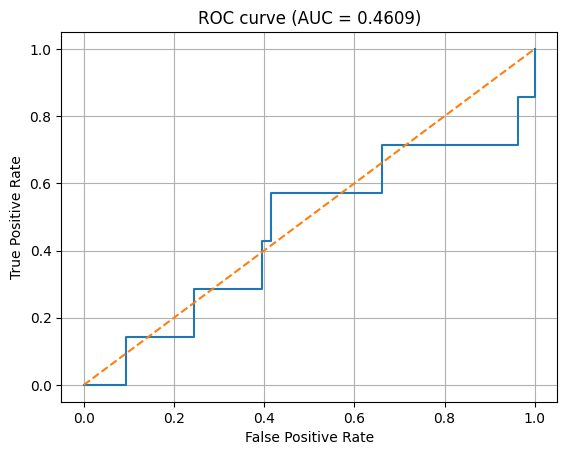

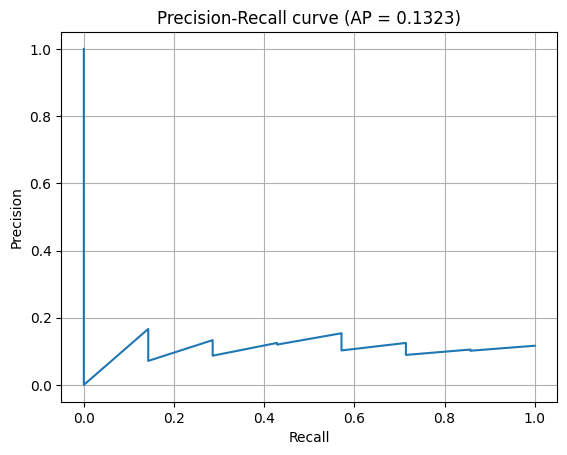

In [5]:
# -------------------------
# EVALUATION: METRICS & CURVES
# -------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import numpy as np

# Ensure X,y exist
assert 'X' in globals() and 'y' in globals(), "X and y must be defined (region features + labels)."

# 1) Split into train / val
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 2) Train a fresh SVM on X_tr (so metrics on X_val are unbiased)
clf = SVC(kernel="linear", probability=True, random_state=42)
clf.fit(X_tr, y_tr)

# 3) Predictions & probabilities on validation set
y_pred = clf.predict(X_val)
y_prob = clf.predict_proba(X_val)[:, 1]  # probability for positive class

# 4) Classification metrics
acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, zero_division=0)
rec = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)
cm = confusion_matrix(y_val, y_pred)

print("Validation set size:", X_val.shape[0])
print("Accuracy : {:.4f}".format(acc))
print("Precision: {:.4f}".format(prec))
print("Recall   : {:.4f}".format(rec))
print("F1-score : {:.4f}".format(f1))
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_val, y_pred, zero_division=0))

# 5) ROC curve + AUC
fpr, tpr, _ = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.title(f"ROC curve (AUC = {roc_auc:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.show()

# 6) Precision-Recall curve + Average Precision
precision, recall, _ = precision_recall_curve(y_val, y_prob)
avg_prec = average_precision_score(y_val, y_prob)
plt.figure()
plt.plot(recall, precision)
plt.title(f"Precision-Recall curve (AP = {avg_prec:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()